# 函嶺洞門：水温・電圧・補助圧力の時系列

**問い**：半日程度と数分の変動は測定分解能や窓長に照らして有効か。65 mだけ振幅が小さい理由に、温度プロファイルの折れ目や地質・水理の情報が使えるか。`DEFI/Data`の5深度は2026年8月27日12:00–29日08:00の共通44時間を使用する。`deoth55.csv`は55 mの原ファイル名。関連する最低限の作業は[実習メモ](熱学実習_最低限の作業.md)を参照。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

root = Path.cwd() / 'DEFI/Data'
files = {20:'depth20.csv', 35:'depth35.csv', 45:'depth45.csv', 55:'deoth55.csv', 65:'depth65.csv'}
data = {}
for depth, name in files.items():
    d = pd.read_csv(root/name, skiprows=25, header=None, usecols=[0,1,2],
                    names=['time','temp','volt'], encoding='cp932')
    d.time = pd.to_datetime(d.time, format='%Y/%m/%d %H:%M:%S')
    d = d.set_index('time').loc[pd.Timestamp('2026-08-27 12:00:00'):pd.Timestamp('2026-08-29 08:00:00')]
    assert len(d)==15841 and d.index.to_series().diff().dropna().nunique()==1
    data[depth] = d
qc = pd.DataFrame({z: [len(d), d.temp.isna().sum(), d.temp.std(), d.volt.min(), d.volt.max()]
                   for z,d in data.items()}, index=['点数','温度欠損','温度SD °C','電圧最小 V','電圧最大 V']).T
display(qc.round(4))

,点数,温度欠損,温度SD °C,電圧最小 V,電圧最大 V
20,15841.0,0.0,0.1148,1.48,1.50
35,15841.0,0.0,0.1152,1.49,1.51
45,15841.0,0.0,0.1128,1.50,1.50
55,15841.0,0.0,0.1122,1.50,1.53
65,15841.0,0.0,0.0419,1.53,1.56


## 44時間の全体像

水温は深度ごとに平均を引いて表示する。電圧はCSVで0.01 V刻みの丸め値で、45 mでは期間中ずっと1.50 Vである。丸め幅より小さい電圧振幅は識別できない。

/var/folders/5p/hk8w18ns5tb0gnz925r91ftm0000gn/T/ipykernel_68021/4275369141.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  ZOOM_END = ZOOM_START + pd.Timedelta(minutes=ZOOM_WIDTH_MIN)


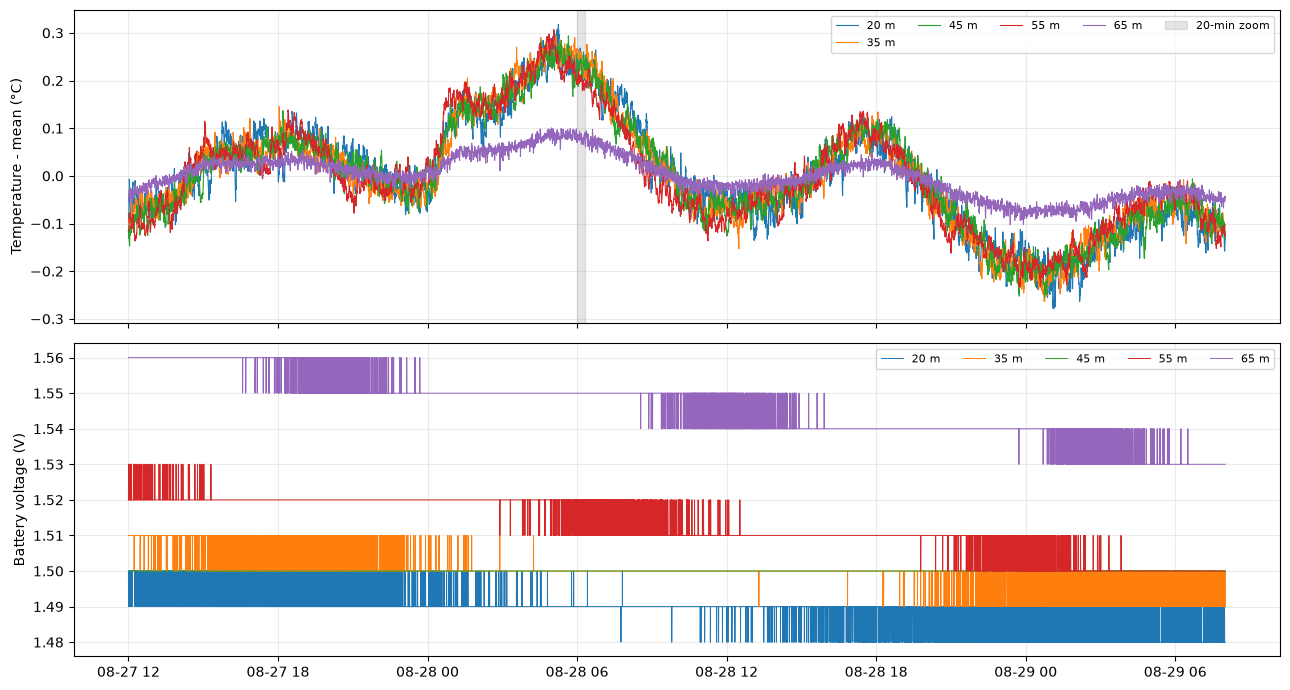

In [2]:
ZOOM_START = pd.Timestamp('2026-08-28 06:00:00')
ZOOM_WIDTH_MIN = 20
ZOOM_END = ZOOM_START + pd.Timedelta(minutes=ZOOM_WIDTH_MIN)

fig, ax = plt.subplots(2,1,figsize=(13,7),sharex=True)
for z,d in data.items():
    ax[0].plot(d.index, d.temp-d.temp.mean(), label=f'{z} m', lw=.8)
    ax[1].plot(d.index, d.volt, label=f'{z} m', lw=.7)
ax[0].axvspan(ZOOM_START, ZOOM_END, color='grey', alpha=.20, label='20-min zoom')
ax[0].set_ylabel('Temperature - mean (°C)'); ax[1].set_ylabel('Battery voltage (V)')
for a in ax: a.grid(alpha=.25); a.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

### 20分間の水温を拡大する

全期間図の灰色帯を拡大する。開始時刻 `ZOOM_START` と幅 `ZOOM_WIDTH_MIN` は直前のコードセルで変更できる。初期設定は**8月28日06:00～06:20**で、10秒値が各深度121点ある。深度ごとの絶対温度差が大きいため、拡大図では**その20分間の平均水温を各系列から引く**。凡例に平均の絶対温度を併記する。こうして10秒ごとの細かな上下動を見られるが、選んだ20分だけを全44時間の代表や周期の証拠とはみなさない。

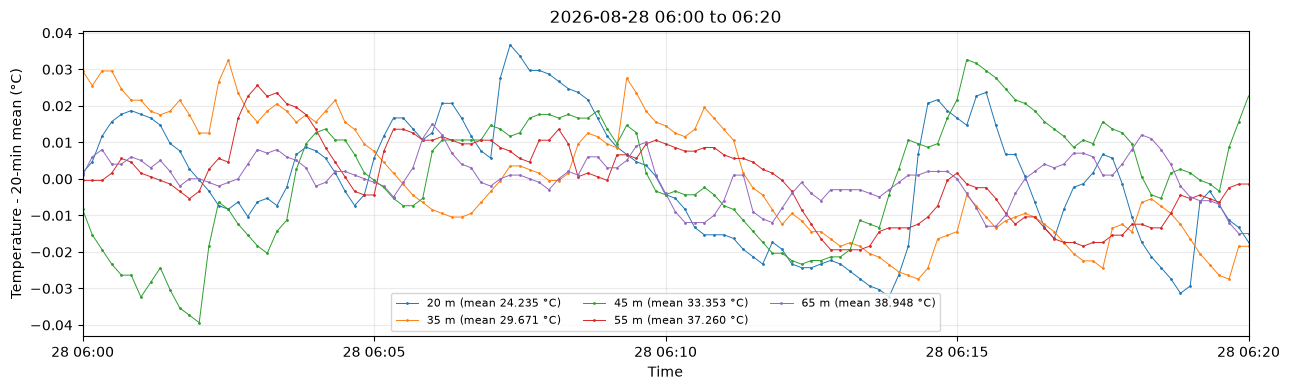

In [3]:
fig, ax = plt.subplots(figsize=(13,4))
for z,d in data.items():
    w = d.loc[ZOOM_START:ZOOM_END, 'temp']
    ax.plot(w.index, w-w.mean(), '.-', ms=2, lw=.7,
            label=f'{z} m (mean {w.mean():.3f} °C)')
ax.set(xlim=(ZOOM_START, ZOOM_END), xlabel='Time',
       ylabel='Temperature - 20-min mean (°C)',
       title=f'{ZOOM_START:%Y-%m-%d %H:%M} to {ZOOM_END:%H:%M}')
ax.grid(alpha=.25); ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# 共通44時間の変化量と深度間の同時性（1分平均）
minute_temp = pd.DataFrame({z:d.temp.resample('1min').mean() for z,d in data.items()})
variation = []
for z,d in data.items():
    variation.append([z,d.temp.max()-d.temp.min(),
                      d.temp.iloc[-360:].mean()-d.temp.iloc[:360].mean(),
                      minute_temp[20].corr(minute_temp[z])])
display(pd.DataFrame(variation,columns=['深度 m','全期間の温度幅 °C',
                                        '終盤1時間−序盤1時間 °C','20 mとの1分値相関']).round(3))

,深度 m,全期間の温度幅 °C,終盤1時間−序盤1時間 °C,20 mとの1分値相関
0,20,0.597,-0.052,1.000
1,35,0.556,-0.033,0.954
2,45,0.549,-0.008,0.957
3,55,0.540,-0.007,0.935
4,65,0.203,-0.017,0.958


### 時間変化は観測されるか

全5深度に実際の時間変化があり、44時間の水温幅は20–55 mで約0.54–0.60 °C、名目65 mで約0.20 °C。20 mと他深度の1分平均の相関は0.94–0.96で、増減の時刻がほぼそろう。終盤1時間の平均は序盤1時間より0.007–0.052 °C低いが、これは**端点間の差**であり、一定速度の冷却を意味しない。図には8月28日未明から朝にかけての昇温と、その後の降温など、単純な正弦波だけでは表せない変化がある。後段の12.42時間振幅0.10–0.11 °C（65 mは0.036 °C）はこの複雑な波形の一成分の大きさであり、全期間の温度幅とは異なる。

**原因の比較**：深度間の同期と、名目65 mだけ振幅が約3分の1になることは、共通の圧力・水位変動への応答、井戸内の縦流れ・混合、または同じ水塊の移動と整合する。補正後約59 mの温度勾配の折れ目との対応、および[過去の箱根実習ポスター p.1](history/箱根過去データ/観測実習ポスター.pdf)の70 m小振幅もこの仮説を強める。`water50m`の独立ログとDEFI 65 mの温度は相関約0.87で、DEFI1台だけの電気的誤差で全波形が生じたとは考えにくい。一方、機器の設置・校正差を完全には除けない。気圧も変化しているが、後段の同時刻照合では気圧の最良周期は13.33時間で水温の12.50–12.55時間と一致せず、二次トレンド除去後の相関は−0.25～−0.32にとどまる。異常な`water50m`圧力値から水位を復元できないため、気圧が水温変動を駆動したかどうかは検証できない。

地表の半日温度変化が**熱伝導だけで20–65 mへ44時間以内に伝わった**という説明は難しい。[過去ポスター pp.1, 4](history/箱根過去データ/観測実習ポスター.pdf)にある浅い土壌の熱拡散率の例、約2×10⁻⁷ m²/sを半日周期に仮に使うと、拡散の浸透深さ `√(κP/π)` は約0.05 mとなる。これは本井戸の岩石の測定値ではなく桁の比較だが、数十mを同時に変える機構としては水の動きや圧力応答を優先して調べる理由になる。

## 長周期の手法：トレンドを含む調和回帰の周期探索

ここで使うのは、**正弦波の最小二乗フィットを候補周期ごとに繰り返す方法（調和回帰／least-squares period scan）**。FFTの最大ビンを読む方法でも、SciPyのLomb–Scargle関数でもない。時刻 (t) を時間単位で表し、各候補周期 (P=8,8.025,…,20) 時間について

\[T(t)=c_0+c_1t+c_2t^2+a\sin(2\pi t/P)+b\cos(2\pi t/P)+\varepsilon(t)\]

を[NumPyの `lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)で推定する。残差平方和が最小の (P) を表の「最良周期」とし、振幅は \(\sqrt{a^2+b^2}\)。`1 - RSS(正弦波込み)/RSS(二次トレンドのみ)` は正弦波を足したことによる見かけの改善率であり、周期が有意である確率ではない。

**採用理由**：10秒の等間隔記録なのでLomb–Scargleが必要な不等間隔問題はない。44時間では通常のFFTの周波数間隔は約1/44 h⁻¹で、半日近くのピークを粗くしか置けない。候補周期を細かく走査し、同時に緩いドリフトを回帰することで、単純なFFTビン選択より位置と振幅を読みやすくできる。1分平均は各6点の細かなノイズを抑え、半日波形は保つ。二次項は緩い非周期変化の近似であり、選び方により周期が動き得る。候補グリッドの0.025時間刻みは**測定の確度ではない**。前半・後半の再計算と深度間の一致で頑健性を点検する。3.5周期しかないため12.00時間と月潮の12.42時間を分離できず、潮汐起源を立証しない（[NOAAの潮汐成分の説明](https://tidesandcurrents.noaa.gov/publications/Understanding_Tides_by_Steacy_finalFINAL11_30.pdf)）。

**「前半」「後半」の定義**：このコードは両端を含む共通窓を1分平均し、2026年8月27日12:00～29日08:00の2,641時刻を `np.array_split(y, 2)` で時系列順に二分する。前半は**8月27日12:00～28日10:00（1,321点）**、後半は**8月28日10:01～29日08:00（1,320点）**。最後の08:00の1分平均だけは元の10秒値1点からなる。各半分について時刻を0から振り直し、同じ8～20時間の周期探索を独立に行う。これは約22時間ずつで推定値が変わらないかを見る簡易点検であり、各半分では半日周期が2回弱しか含まれないため精度は低い。

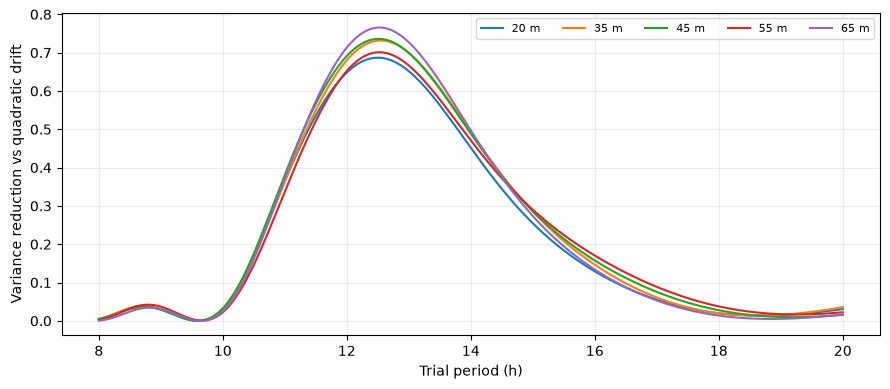

,深度 m,全期間の最良周期 h,12.42 h振幅 °C,改善率,前半の周期 h,後半の周期 h
0,20,12.500,0.100,0.687,13.400,12.125
1,35,12.550,0.110,0.732,13.775,12.200
2,45,12.500,0.105,0.736,13.025,12.300
3,55,12.525,0.109,0.701,13.875,12.200
4,65,12.525,0.036,0.766,14.000,12.350


In [5]:
def fit_wave(y, t, period):
    base = np.column_stack([np.ones(len(t)), t, t*t])
    design = np.column_stack([base, np.sin(2*np.pi*t/period), np.cos(2*np.pi*t/period)])
    c = np.linalg.lstsq(design, y, rcond=None)[0]
    return np.sum((y-design@c)**2), np.hypot(c[-2],c[-1]), design@c

periods = np.arange(8,20.001,.025)
long_rows = []
fig, ax = plt.subplots(figsize=(9,4))
for z,d in data.items():
    y = d.temp.resample('1min').mean().to_numpy()
    t = np.arange(len(y))/60
    errors = np.array([fit_wave(y,t,p)[0] for p in periods])
    best = periods[np.argmin(errors)]
    base = np.column_stack([np.ones(len(t)),t,t*t])
    c = np.linalg.lstsq(base,y,rcond=None)[0]
    rss0 = np.sum((y-base@c)**2)
    _,amp,_ = fit_wave(y,t,12.42)
    halves = []
    for yy in np.array_split(y,2):
        tt = np.arange(len(yy))/60
        halves.append(periods[np.argmin([fit_wave(yy,tt,p)[0] for p in periods])])
    long_rows.append([z,best,amp,1-min(errors)/rss0,*halves])
    ax.plot(periods,1-errors/rss0,label=f'{z} m')
ax.set(xlabel='Trial period (h)',ylabel='Variance reduction vs quadratic drift')
ax.grid(alpha=.25); ax.legend(ncol=5,fontsize=8); plt.tight_layout(); plt.show()
long_result = pd.DataFrame(long_rows,columns=['深度 m','全期間の最良周期 h','12.42 h振幅 °C','改善率','前半の周期 h','後半の周期 h'])
display(long_result.round(3))

5深度の最良値は約12.5時間に集まり、12.42時間を固定した水温振幅は20–55 mで約0.100–0.110 °C、65 mで約0.036 °C。二次トレンドだけより残差平方和は減る。約12.5時間は[NOAAの潮汐成分表](https://prod.tidesandcurrents.noaa.gov/publications/tidal_datums_and_their_applications.pdf)にある月の半日潮M₂の12.42時間と約0.08時間（約5分）しか違わず、**潮汐または潮汐に応じた地下水位変動が候補**となる。しかし前半だけの最良値は約13–14時間、後半は約12.1–12.4時間に動く。44時間では太陽半日潮S₂の12.00時間との分離や、水位との位相・振幅対応を確認できない。したがって半日程度の共通変動は再現するが、12.500時間という精密な周期値と潮汐起源は未確定である。

In [6]:
upper = long_result.query('`深度 m` < 65')['12.42 h振幅 °C'].median()
deep = long_result.query('`深度 m` == 65')['12.42 h振幅 °C'].iloc[0]
print(f'65 mの振幅: {deep:.3f} °C / 20–55 m中央値: {upper:.3f} °C = {deep/upper:.2f}倍')

65 mの振幅: 0.036 °C / 20–55 m中央値: 0.107 °C = 0.34倍


**65 mが小さい理由の候補**：2026年のプロファイルは補正後約58.07–59.07 mの折れ目を挟んで平均勾配が+0.375から+0.095 °C/mへ低下し、DEFIの名目65 mはその下側にある。プロファイルと同じ深度基準なら65.07 mに相当するが、ロガー設置深度の基準は要照合。上側4深度の半日振幅の中央値に対し、65 mは約0.34倍。温度勾配の変化と振幅低下が同じ深度帯にある点は、地下水の流入・混合、割れ目分布、岩相や熱物性の変化で水温応答が変わる仮説と整合する。[USGSの温度検層解説](https://www.usgs.gov/media/images/geophysical-logs-temperature-logs)も低勾配を孔内流動の手掛かりとする。過去の[箱根観測実習ポスター p.1](history/箱根過去データ/観測実習ポスター.pdf)でも70 mで小振幅と記され、類似する深度依存性が先例にある。ただし計器校正差、設置状態、振幅の時間変化を除外できず、65 mの地層名や流れの向きは決められない。50–75 mの流速・流向、電気伝導度、孔壁・スクリーン構造を同時に測る必要がある。

## 10分以内の短周期探索：Welch法

10秒間隔の原データから30分移動平均を引き、長い変動を弱める。10秒サンプリングのナイキスト限界は20秒なので、**20秒～10分の全周波数ビン**を探索する。20秒付近は1周期に2測点しかなく形を十分に表せないため、短い端の解釈には特に注意する。3分を探索の中心や固定の答えにはしない。

[SciPyのWelch法](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html)で約5.7時間の窓を半分重ねてパワースペクトル密度を平均し、範囲内で最大のビンを各深度の**候補**として表示する。同じ操作を前半・後半に行い、20 mとの[コヒーレンス](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.coherence.html)を**各深度自身の最大ピーク周波数**で照合する。表の3分固定振幅は、当初の3分仮説を別途点検する参考値であり、最大ピークの選択には使わない。どんなノイズにも範囲内の最大値は存在するので、最大値だけを「有効な周期」とは呼ばない。

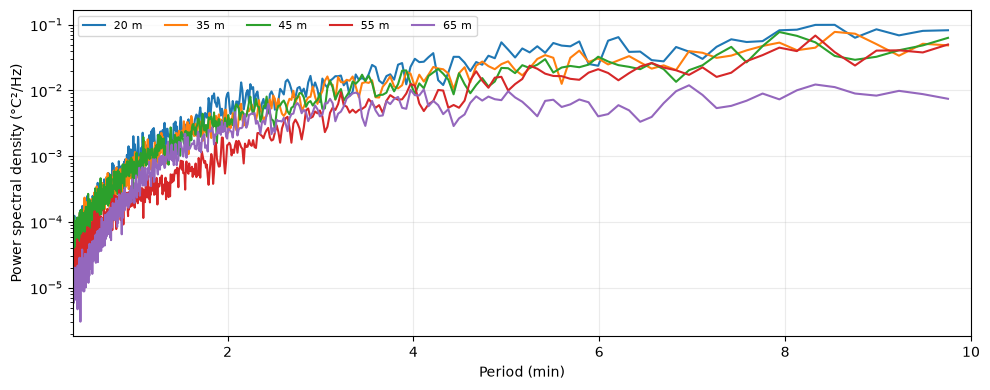

,深度 m,20秒～10分の最大ピーク min,前半の最大ピーク min,後半の最大ピーク min,最大ピークでの20mとのコヒーレンス,参考：3分固定振幅 °C
0,20,8.5333,8.3252,7.9380,1.0000,0.0001
1,35,8.5333,8.5333,7.9380,0.0824,0.0004
2,45,7.9380,7.9380,9.7524,0.0059,0.0001
3,55,8.3252,9.7524,8.3252,0.0936,0.0002
4,65,8.3252,9.2252,8.3252,0.1024,0.0003


In [7]:
MIN_PERIOD_MIN = 20/60  # 10秒サンプリングのナイキスト限界
MAX_PERIOD_MIN = 10

def peak_in_band(x):
    f,power = signal.welch(x,fs=.1,nperseg=2048,noverlap=1024)
    minutes = np.divide(1,60*f,out=np.full_like(f,np.inf),where=f>0)
    use = (minutes>=MIN_PERIOD_MIN)&(minutes<=MAX_PERIOD_MIN)
    k = np.flatnonzero(use)[np.argmax(power[use])]
    return f,power,minutes,use,k

short_rows=[]
fig,ax=plt.subplots(figsize=(10,4))
reference=(data[20].temp-data[20].temp.rolling(180,center=True,min_periods=1).mean()).to_numpy()
for z,d in data.items():
    high=(d.temp-d.temp.rolling(180,center=True,min_periods=1).mean()).to_numpy()
    f,power,minutes,use,k=peak_in_band(high)
    halves=[]
    for h in np.array_split(high,2):
        _,_,hm,_,hk=peak_in_band(h)
        halves.append(hm[hk])
    fc,coh=signal.coherence(reference,high,fs=.1,nperseg=2048)
    sec=np.arange(len(high))*10
    X=np.column_stack([np.sin(2*np.pi*sec/180),np.cos(2*np.pi*sec/180)])
    amp3=np.linalg.norm(np.linalg.lstsq(X,high,rcond=None)[0])
    short_rows.append([z,minutes[k],*halves,coh[np.argmin(abs(fc-f[k]))],amp3])
    ax.plot(minutes[use],power[use],label=f'{z} m')
ax.set(xlim=(MIN_PERIOD_MIN,MAX_PERIOD_MIN),xlabel='Period (min)',
       ylabel='Power spectral density (°C²/Hz)')
ax.set_yscale('log');ax.grid(alpha=.25);ax.legend(ncol=5,fontsize=8)
plt.tight_layout();plt.show()
short_result=pd.DataFrame(short_rows,columns=['深度 m','20秒～10分の最大ピーク min',
    '前半の最大ピーク min','後半の最大ピーク min','最大ピークでの20mとのコヒーレンス',
    '参考：3分固定振幅 °C'])
display(short_result.round(4))

20秒～10分を探索しても、全期間の最大ピークは各深度で約7.94～8.53分にあり、従来の2～10分探索と変わらない。ただし前半・後半の最大値は約7.94～9.75分に動き、同じ狭い周期としては安定しない。20 mとのコヒーレンスを各深度の最大ピーク周波数で見ると、20 m自身の1は自明で、他の深度は約0.006～0.102と低い。**8分前後にパワーの山はあるが、全深度で同じ安定した振動とはまだ認めない。**

3分は探索範囲に含まれているが、共通する鋭いピークはない。参考の3分固定振幅は約0.0001–0.0004 °Cで、CSVの0.001 °C刻みより小さい。刻みより小さい振幅も平均化で推定できる場合はあるため、この比較だけで棄却せず、ピーク形・前後半の再現・深度間コヒーレンスを合わせて判断する。10秒間隔でサンプリング可能なことと、実在する周期を検出できたことは別である。

### 20 mの7～8分・8～9分候補を個別に検証する

20分拡大図で20 mに見える数分の揺れを、**44時間のスペクトルと時間帯ごとの再現性**で調べる。30分移動平均を除いた水温のWelchスペクトルで7～8分・8～9分の山を比べ、8～9分の正弦波を全期間に固定してどれだけ水温変化を説明できるかも確認する。さらに端の1点を除く44時間を重ならない4時間×11区間に分け、各区間の6～10分の候補に「二次の緩い変化＋正弦・余弦」を最小二乗で当てはめる。4時間なら8分周期が約30回入る。区間ごとに最良周期が8～9分へ集中するかを見る。探索範囲内の最大値は必ず得られるため、残差減少率は有意確率ではない。

PSD最大: 7–8分帯 7.938分、8–9分帯 8.533分、前者/後者 0.83
全期間の8–9分調和回帰: 最良8.59分、振幅0.0023 °C、残差減少率0.006


,4時間区間の開始,最良周期 min,振幅 °C,残差減少率
0,2026-08-27 12:00:00,7.20,0.0048,0.027
1,2026-08-27 16:00:00,9.45,0.0055,0.038
2,2026-08-27 20:00:00,8.70,0.0057,0.036
3,2026-08-28 00:00:00,8.45,0.0072,0.062
4,2026-08-28 04:00:00,6.25,0.0053,0.039
5,2026-08-28 08:00:00,8.45,0.0053,0.027
6,2026-08-28 12:00:00,7.90,0.0053,0.034
7,2026-08-28 16:00:00,10.00,0.0060,0.035
8,2026-08-28 20:00:00,8.10,0.0067,0.037
9,2026-08-29 00:00:00,9.85,0.0045,0.024


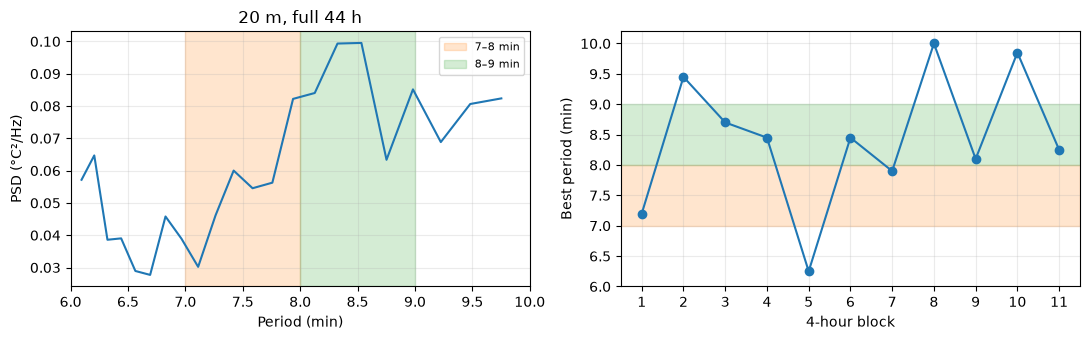

In [8]:
high20=(data[20].temp-data[20].temp.rolling(180,center=True,min_periods=1).mean()).to_numpy()
f,power,minutes,_,_=peak_in_band(high20)
band78=(minutes>=7)&(minutes<=8)
band89=(minutes>=8)&(minutes<=9)
band610=(minutes>=6)&(minutes<=10)
k78=np.flatnonzero(band78)[np.argmax(power[band78])]
k89=np.flatnonzero(band89)[np.argmax(power[band89])]
print(f'PSD最大: 7–8分帯 {minutes[k78]:.3f}分、8–9分帯 {minutes[k89]:.3f}分、前者/後者 {power[k78]/power[k89]:.2f}')

# 全期間で位相が一定の8～9分波を仮定したときの説明力
t_all=np.arange(len(high20))/360
base_all=np.column_stack([np.ones(len(high20)),t_all,t_all*t_all])
c=np.linalg.lstsq(base_all,high20,rcond=None)[0]
rss0_all=np.sum((high20-base_all@c)**2)
trial89=np.arange(8,9.001,.01)
fits89=[fit_wave(high20,t_all,P/60)[:2] for P in trial89]
k=np.argmin([rss for rss,amp in fits89])
print(f'全期間の8–9分調和回帰: 最良{trial89[k]:.2f}分、振幅{fits89[k][1]:.4f} °C、残差減少率{1-fits89[k][0]/rss0_all:.3f}')

trial=np.arange(6,10.001,.05)
blocks=[]
for j in range(11):
    y=high20[j*1440:(j+1)*1440]  # 10秒×1440点 = 4時間
    t=np.arange(len(y))/360
    base=np.column_stack([np.ones(len(y)),t,t*t])
    c=np.linalg.lstsq(base,y,rcond=None)[0]
    rss0=np.sum((y-base@c)**2)
    fits=[fit_wave(y,t,P/60)[:2] for P in trial]
    k=np.argmin([rss for rss,amp in fits])
    blocks.append([data[20].index[j*1440],trial[k],fits[k][1],1-fits[k][0]/rss0])
block20=pd.DataFrame(blocks,columns=['4時間区間の開始','最良周期 min','振幅 °C','残差減少率'])
display(block20.round({'最良周期 min':2,'振幅 °C':4,'残差減少率':3}))

fig,ax=plt.subplots(1,2,figsize=(11,3.5))
ax[0].plot(minutes[band610],power[band610])
ax[0].axvspan(7,8,color='tab:orange',alpha=.2,label='7–8 min')
ax[0].axvspan(8,9,color='tab:green',alpha=.2,label='8–9 min')
ax[1].axhspan(7,8,color='tab:orange',alpha=.2)
ax[1].axhspan(8,9,color='tab:green',alpha=.2)
ax[0].set(xlim=(6,10),xlabel='Period (min)',ylabel='PSD (°C²/Hz)',title='20 m, full 44 h')
ax[0].legend(fontsize=8)
ax[1].plot(range(1,12),block20['最良周期 min'],'o-')
ax[1].set(xticks=range(1,12),ylim=(6,10.2),xlabel='4-hour block',ylabel='Best period (min)')
for a in ax:a.grid(alpha=.25)
plt.tight_layout();plt.show()

**結果**：20 mの44時間Welchスペクトルの最大は**8.53分**で、8～9分帯に入る。隣の7～8分帯にも**7.94分**の山があり、そのPSDは8.53分の約**0.83倍**。8～9分だけに孤立した鋭い線ではなく、数分幅に広がる。前後半の最大ピークも8.33分と7.94分で少し動く。

全期間に位相の一定した8～9分の正弦波を当てると、最良値は**8.59分**、振幅は約**0.0023 °C**、二次トレンドからの残差減少率は約**0.006**（0.6%）。一方、重ならない4時間区間の最良値は**6.25～10.00分**に散らばり、8～9分に入るのは**11区間中5区間**。各区間の残差減少率は約**0.024～0.062**。全期間で位相が一定の波より、局所的に強弱や周期が変わる揺れの方がデータに合う。

よって**8～9分の変動は20 mの有力な短周期候補**だが、44時間を通じた一定周期・一定位相の振動とは確認できない。20分図だけでは約2～3周期しか見えず、流速・正常な水圧など独立量との同期や、別日の再現で実在性をさらに確かめる必要がある。

## 電圧との照合と限界

電圧についても12.42時間と3分の振幅を計算するが、CSVの表示刻み0.01 V未満は有効数字として扱わない。

In [9]:
rows=[]
for z,d in data.items():
    y=d.volt.resample('1min').mean().to_numpy(); t=np.arange(len(y))/60
    _,a12,_=fit_wave(y,t,12.42)
    raw=d.volt.to_numpy(); sec=np.arange(len(raw))*10
    X=np.column_stack([np.ones(len(raw)),sec,np.sin(2*np.pi*sec/180),np.cos(2*np.pi*sec/180)])
    c=np.linalg.lstsq(X,raw,rcond=None)[0]
    rows.append([z,d.volt.nunique(),a12,np.hypot(c[-2],c[-1])])
display(pd.DataFrame(rows,columns=['深度 m','電圧の異なる値の数','12.42 h振幅 V','3分振幅 V']).round(5))

,深度 m,電圧の異なる値の数,12.42 h振幅 V,3分振幅 V
0,20,3,0.00021,0.00008
1,35,3,0.00021,0.00010
2,45,1,0.00000,0.00000
3,55,4,0.00087,0.00003
4,65,4,0.00113,0.00008


## `Air_Append` と `water50m` の補助ログ

両CSVはIn-Situ Rugged TROLL 100のログで、ファイル先頭に機器・記録設定、68行目以降に1分間隔の日時、圧力、温度、`Depth` がある。エクスポート日は8月31日でも**データは8月27日09:00–29日13:00の3121点**で終わる。共通44時間には各2641点があり、この部分の日時・数値は欠損しない。8月29日13時以降はDEFI水温と照合できる補助記録がない。両ファイルの`Depth (cm)`は装置のDepthモードの換算値で、井戸内の設置深度とは限らない。

,ログ,全点数,開始,終了,共通窓点数,共通窓欠損,圧力最小 kPa,圧力最大 kPa,温度最小 °C,温度最大 °C
0,Air,3121,2026-08-27 09:00:00,2026-08-29 13:00:00,2641,0,99.436,99.982,25.146,29.602
1,water50m,3121,2026-08-27 09:00:00,2026-08-29 13:00:00,2641,0,-376.669,-376.655,38.934,39.211


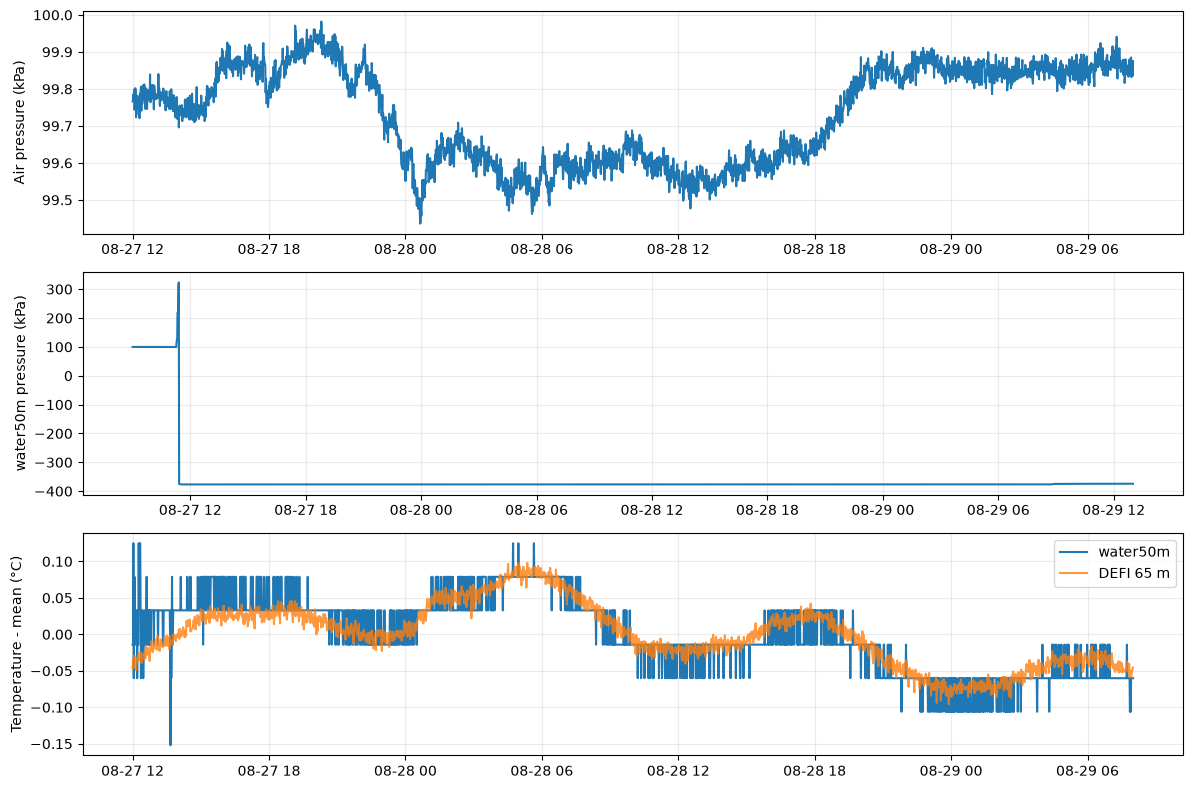

water50m温度とDEFI 65 m温度の相関: 0.872


In [10]:
aux = {}
for key,pattern in [('Air','Air_Append_*.csv'),('water50m','water50m_*.csv')]:
    p = next(root.parent.glob(pattern))
    d = pd.read_csv(p,skiprows=67,header=None,usecols=[0,2,3,4],
                    names=['time','pressure','temp','depth'])
    d.time = pd.to_datetime(d.time.str.strip(),format='%m/%d/%Y %I:%M:%S %p')
    aux[key] = d.set_index('time')

start,end = pd.Timestamp('2026-08-27 12:00'),pd.Timestamp('2026-08-29 08:00')
rows=[]
for key,d in aux.items():
    w=d.loc[start:end]
    rows.append([key,len(d),str(d.index.min()),str(d.index.max()),len(w),
                 w.isna().sum().sum(),w.pressure.min(),w.pressure.max(),
                 w.temp.min(),w.temp.max()])
display(pd.DataFrame(rows,columns=['ログ','全点数','開始','終了','共通窓点数','共通窓欠損',
                                   '圧力最小 kPa','圧力最大 kPa','温度最小 °C','温度最大 °C']).round(3))

fig,ax=plt.subplots(3,1,figsize=(12,8))
ax[0].plot(aux['Air'].loc[start:end].index,aux['Air'].loc[start:end].pressure)
ax[0].set_ylabel('Air pressure (kPa)')
ax[1].plot(aux['water50m'].index,aux['water50m'].pressure)
ax[1].set_ylabel('water50m pressure (kPa)')
water_t=aux['water50m'].loc[start:end].temp
deep_t=data[65].temp.resample('1min').mean()
ax[2].plot(water_t.index,water_t-water_t.mean(),label='water50m')
ax[2].plot(deep_t.index,deep_t-deep_t.mean(),label='DEFI 65 m',alpha=.8)
ax[2].set_ylabel('Temperature - mean (°C)');ax[2].legend()
for a in ax:a.grid(alpha=.25)
plt.tight_layout();plt.show()
print('water50m温度とDEFI 65 m温度の相関:',round(water_t.corr(deep_t),3))

**読めること**：`Air_Append`の共通窓の気圧は99.436–99.982 kPa、温度は25.146–29.602 °Cで、環境条件の参考になる。`water50m`の温度は38.934–39.211 °Cで、DEFI 65 mと似た時間変化（1分値の相関約0.87）を示す。ただしファイル名だけでは実際の設置深度は確認できず、温度の記録刻みも粗いので「50 mの独立した精密測定」とは扱わない。

`water50m`の圧力は設置中8月27日11:25に負へ飛び、共通窓では約−376.67～−376.66 kPa、対応する`Depth`も約−3845 cmで非物理的。メタデータには9 m/30 ft用の圧力センサーと記され、過大な水柱圧による測定範囲外・変換異常が疑われるが、故障原因は記録だけでは確定できない。**この圧力・深度欄から水位や周期を求めない**。気圧は水位補正に有用だが、水圧側が正常でないため、この2本だけで半日水位変動を検証できない。

## 気圧と水温の周期を同じ44時間で照合する

`DEFI/Air_Append_2026-08-31_10-17-39-444.csv`の気圧と、`DEFI/Data/depth20.csv`・`depth35.csv`・`depth45.csv`・`deoth55.csv`・`depth65.csv`の水温を2026年8月27日12:00–29日08:00の**同じ1分時刻**にそろえる。気圧は`Air_Append`の圧力列のみを使い、異常な`water50m`の圧力は使わない。

長周期は上と同じ**二次トレンドを含む調和回帰**で気圧の8–20時間を探索し、12.42時間固定の振幅も計算する。気圧と各深度の水温について、元系列の相関と、各系列から別々に二次トレンドを除いた**同時刻（遅れ0）の相関**を比べる。図の標準化残差は形を見るためのもので、気圧と水温の振幅を同じ単位にした値ではない。8.3分については1分系列から30分移動平均を引き、[SciPyのコヒーレンス](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.coherence.html)で気圧との一致を試す。短い窓での相関・コヒーレンスには有意確率を付けず、圧力から水温の原因を断定しない。

気圧が地下水位に影響し得ることは[USGSの観測研究](https://www.usgs.gov/publications/aquifer-response-record-low-barometric-pressures-southeastern-united-states)で示されているが、**水温への経路と時間遅れはこの井戸で未測定**である。月の半日潮M₂は[NOAAの潮汐成分表](https://prod.tidesandcurrents.noaa.gov/publications/tidal_datums_and_their_applications.pdf)にある12.42時間を参考にする。

/var/folders/5p/hk8w18ns5tb0gnz925r91ftm0000gn/T/ipykernel_68021/845386264.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  assert len(comparison) == 2641 and comparison.index.to_series().diff().dropna().eq(pd.Timedelta('1min')).all()


,系列,全期間の最良周期 h,12.42 h振幅 kPa,12.42 hでの改善率,前半の周期 h,後半の周期 h
0,Air,13.325,0.078,0.365,14.25,17.675


,深度 m,元系列の同時刻相関,二次トレンド除去後の同時刻相関,8.3分の気圧とのコヒーレンス
0,20,-0.506,-0.249,0.495
1,35,-0.525,-0.313,0.274
2,45,-0.525,-0.262,0.287
3,55,-0.513,-0.318,0.083
4,65,-0.516,-0.279,0.147


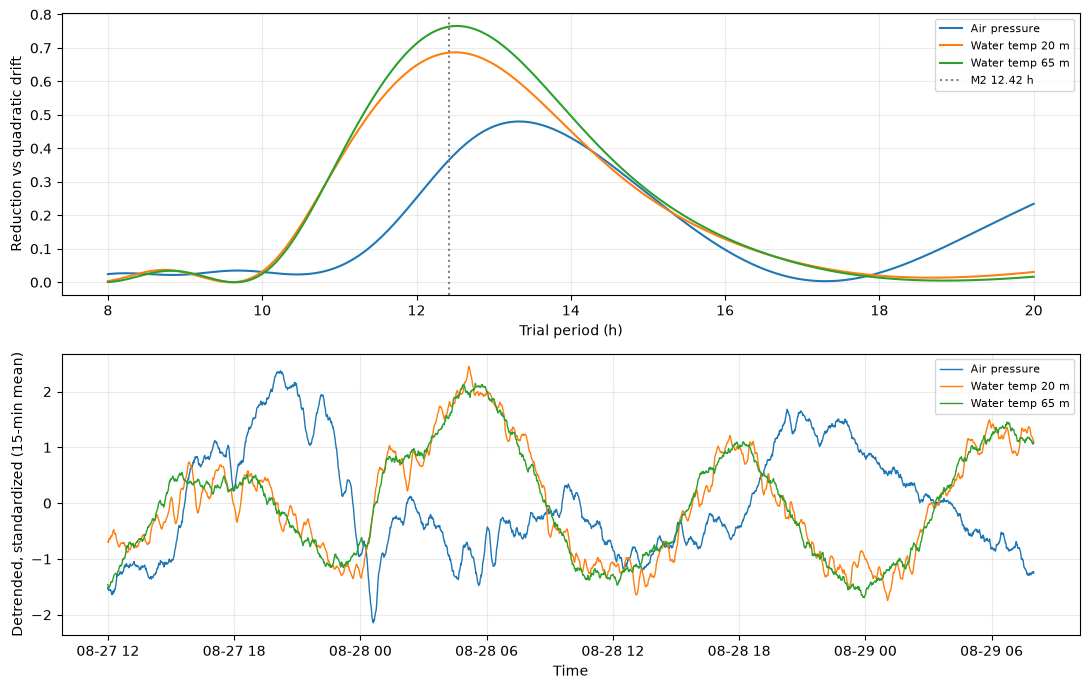

In [11]:
# 気圧とDEFI水温を同一時刻に結合し、周期・相関を並べて点検
air_pressure = aux['Air'].loc[start:end, 'pressure'].rename('Air kPa')
one_minute = {z: d.temp.resample('1min').mean().rename(f'{z} m') for z, d in data.items()}
comparison = pd.concat([air_pressure, *one_minute.values()], axis=1).dropna()
assert len(comparison) == 2641 and comparison.index.to_series().diff().dropna().eq(pd.Timedelta('1min')).all()

time_h = np.arange(len(comparison)) / 60
base = np.column_stack([np.ones(len(time_h)), time_h, time_h**2])
residuals = {}
for column in comparison:
    y = comparison[column].to_numpy()
    residuals[column] = y - base @ np.linalg.lstsq(base, y, rcond=None)[0]

air_y = comparison['Air kPa'].to_numpy()
air_errors = np.array([fit_wave(air_y, time_h, p)[0] for p in periods])
air_best = periods[np.argmin(air_errors)]
air_rss12, air_amp12, _ = fit_wave(air_y, time_h, 12.42)
air_improvement12 = 1 - air_rss12 / np.sum(residuals['Air kPa']**2)
air_half_periods = []
for segment in np.array_split(air_y, 2):
    segment_t = np.arange(len(segment)) / 60
    air_half_periods.append(periods[np.argmin([fit_wave(segment, segment_t, p)[0] for p in periods])])
display(pd.DataFrame([['Air', air_best, air_amp12, air_improvement12,
                       *air_half_periods]], columns=['系列', '全期間の最良周期 h',
                       '12.42 h振幅 kPa', '12.42 hでの改善率',
                       '前半の周期 h', '後半の周期 h']).round(3))

air_high = comparison['Air kPa'] - comparison['Air kPa'].rolling(30, center=True, min_periods=1).mean()
relation_rows = []
for z in data:
    column = f'{z} m'
    temp_high = comparison[column] - comparison[column].rolling(30, center=True, min_periods=1).mean()
    freq, coherence = signal.coherence(air_high.to_numpy(), temp_high.to_numpy(),
                                        fs=1/60, nperseg=512, noverlap=256)
    coh_8min = coherence[np.argmin(abs(freq - 1/(8.3*60)))]
    relation_rows.append([z, comparison['Air kPa'].corr(comparison[column]),
                          np.corrcoef(residuals['Air kPa'], residuals[column])[0,1], coh_8min])
air_relation = pd.DataFrame(relation_rows, columns=['深度 m', '元系列の同時刻相関',
    '二次トレンド除去後の同時刻相関', '8.3分の気圧とのコヒーレンス'])
display(air_relation.round(3))

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
for column, label in [('Air kPa', 'Air pressure'), ('20 m', 'Water temp 20 m'),
                      ('65 m', 'Water temp 65 m')]:
    y = comparison[column].to_numpy()
    errs = np.array([fit_wave(y, time_h, p)[0] for p in periods])
    ax[0].plot(periods, 1 - errs / np.sum(residuals[column]**2), label=label)
    scaled = residuals[column] / np.std(residuals[column])
    ax[1].plot(comparison.index, pd.Series(scaled, index=comparison.index).rolling(15, center=True,
                   min_periods=1).mean(), label=label, lw=1)
ax[0].axvline(12.42, color='grey', ls=':', label='M2 12.42 h')
ax[0].set(xlabel='Trial period (h)', ylabel='Reduction vs quadratic drift')
ax[1].set(ylabel='Detrended, standardized (15-min mean)', xlabel='Time')
for a in ax:
    a.grid(alpha=.25); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**結果の読み方**：気圧の全期間の最良値は約**13.33時間**で、水温5深度の約**12.50–12.55時間**とは一致しない。気圧の12.42時間固定振幅は約**0.078 kPa**、二次トレンドからの改善率は約**0.365**。気圧を半分ずつにすると最良値は約**14.25時間**と**17.68時間**へ動き、気圧の半日周期を安定した成分とは呼べない。元系列は気圧と水温で約−0.51～−0.53の相関を示すが、各系列の二次トレンドを除くと同時刻相関は約**−0.25～−0.32**に弱まる。したがって、共有する緩い変化が元系列の相関を強めている。8.3分帯の気圧とのコヒーレンスは20 mで約0.50、他の深度では約0.08–0.29と揃わず、共通の短周期擾乱を示す証拠にはならない。

**限界**：遅れ0の相関が弱くても、遅れて伝わる気圧応答は除外できない。気圧と水温の双方に短い観測窓・強い自己相関・気象変化の影響があり、探索した最良周期や相関は因果関係・有意確率を表さない。気圧変化が地下水位や流動を介して水温に効くのか、潮汐や揚水が共通要因なのかを分けるには、正常な水圧／水位、流速、気圧、降雨・揚水履歴を数週間以上同期して測る必要がある。

## 次に必要な値とデータ

| 求めたいもの | 次に入手するデータ |
|---|---|
| 半日変動の安定した周期、気圧・地球潮汐・地下水流動との関係 | 数週間以上の同期した水温・気圧・正常な水圧／水位、降雨・揚水記録。12.00 hと12.42 hを分離するには約14.8日以上の観測長が目安 |
| 65 mで振幅が減る原因 | 55–70 mに追加した温度計、各温度計の校正・深度固定記録、深度別流速・流向・電気伝導度、井戸の柱状図とスクリーン位置 |
| `water50m`から真の水位を得ること | 実設置深度、機器仕様・校正履歴、想定水柱に合う測定レンジの圧力計、気圧による補正と同時検尺 |
| 10分以内の短周期候補の再判定 | より長い連続記録、同時計器による再現、校正・時刻同期、流速・水圧の同時高頻度測定 |

現状の結論は「水温の半日程度の共通変動は観測される」「65 mの振幅は上の深度より小さい」「3分の有効周期と電圧周期は確認できない」である。